## Downscaling NDVI and NDWI rasters to 30m 
To have same-level scale with LST images

In [ ]:
!pip install rasterio
!pip install geopandas
!pip install tqdm
!pip install matplotlib
!pip install scipy
!pip install scikit-gstat



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import glob
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import numpy as np
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr



In [ ]:
lst_path = 'LC09_L2SP_192029_20240809_20240810_02_T1_ST_B10.tif' 
bound = "../../datos-notebooks/bologne_boundary.geojson"

In [ ]:
# checking the LST image

with rasterio.open(lst_path) as src:
    product1 = src.read(1) * 0.00341802 - 124.15  # °C
    transform = src.transform
    crs = src.crs
    res = src.res  # pixel size (x and y)
    bounds = src.bounds  # total extension
    width, height = src.width, src.height

print("CRS:", crs)
print("Resolution (m):", res)
print("Extension:", bounds)
print("Dimensions:", width, "x", height)


CRS: EPSG:32632
Resolution (m): (30.0, 30.0)
Extension: BoundingBox(left=586485.0, bottom=4825485.0, right=816015.0, top=5058615.0)
Dimensions: 7651 x 7771


## downscaling

1. Converts the class of interest into a binary mask (1 if pixel belongs to the class, 0 otherwise).  
2. Resamples and aggregates the binary mask to the 30 m LST grid using the average, computing the proportion of pixels of that class within each 30 m pixel, aligned with a reference LST raster. 

In [14]:
mosaic_ndvi_path = "../../datos-notebooks/ndvi_mosaic.tif"  # mosaic NDVI
mosaic_ndwi_path = "../../datos-notebooks/ndwi_mosaic.tif"  # mosaic NDWI

### NDVI

In [ ]:
# NDVI
# --- Parameters ---
classes = [0, 0.5, 1]                            # NDVI classes
output_folder = "ndvi_pct_30m/"                

# --- open LST for spatial reference ---
with rasterio.open(lst_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# --- Initialize accumulators by class ---
accumulators = {val: np.zeros(lst_shape, dtype=np.float32) for val in classes}
os.makedirs(output_folder, exist_ok=True)

# --- Read NDVI mosaic ---
with rasterio.open(mosaic_ndvi_path) as src_ndvi:
    ndvi_data = src_ndvi.read(1).astype(float)
    ndvi_transform = src_ndvi.transform
    ndvi_crs = src_ndvi.crs

# --- Process classes ---
for val in tqdm(classes, desc="Reprojecting NDVI classes"):
    mask_class = (ndvi_data == val).astype(float)
    resampled = np.empty(lst_shape, dtype=np.float32)

    reproject(
        source=mask_class,
        destination=resampled,
        src_transform=ndvi_transform,
        src_crs=ndvi_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )

    accumulators[val] += resampled  # in this case, it's just one mosaic

# --- Save results ---
for val in classes:
    out_profile = lst_profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    out_path = f"{output_folder}ndvi_class{str(val).replace('.', 'p')}_total_30m.tif"

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(accumulators[val], 1)

    print(f"Class {val} saved in {out_path}")

# Very heavy, does not run in jupyterlab with 8gb of RAM

Reproyectando clases NDVI: 100%|██████████| 3/3 [01:38<00:00, 32.72s/it]


Clase 0 guardada en ndvi_pct_30m/ndvi_class0_total_30m.tif
Clase 0.5 guardada en ndvi_pct_30m/ndvi_class0p5_total_30m.tif
Clase 1 guardada en ndvi_pct_30m/ndvi_class1_total_30m.tif


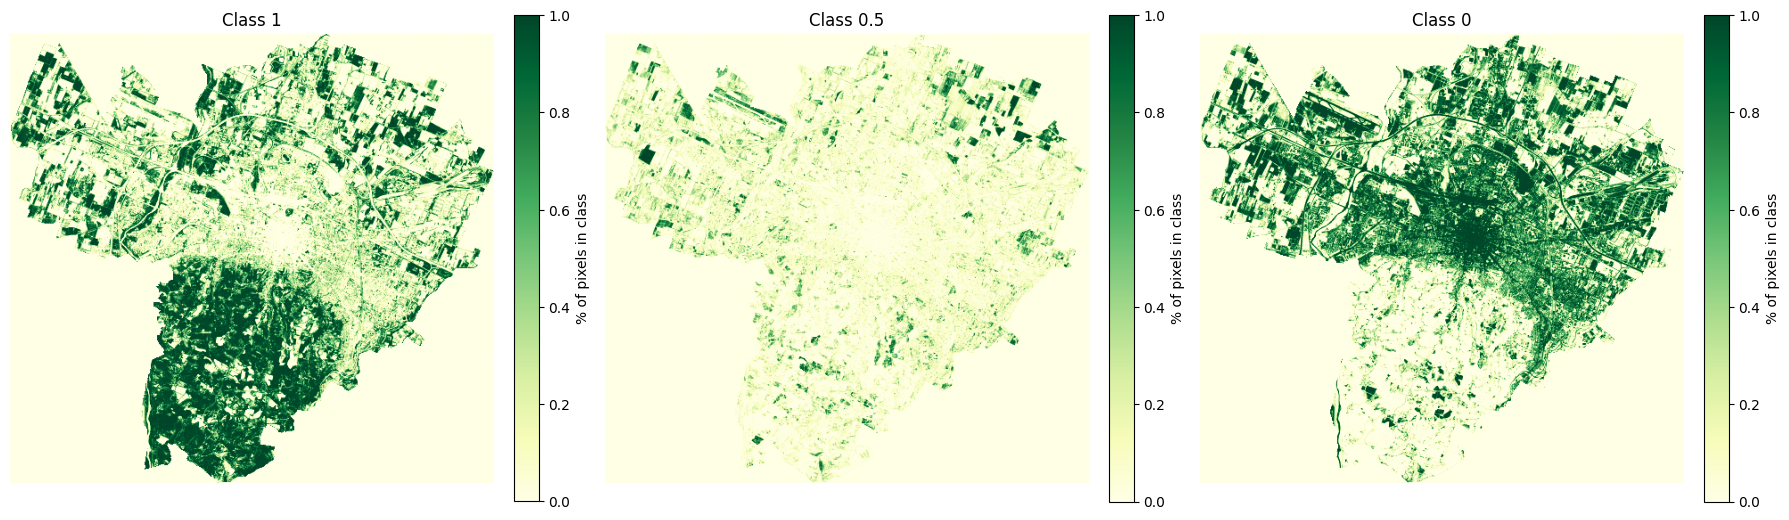

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

ndvi_paths = {
    "Class 1": "ndvi_pct_30m/ndvi_class1_total_30m.tif",
    "Class 0.5": "ndvi_pct_30m/ndvi_class0p5_total_30m.tif",
    "Class 0": "ndvi_pct_30m/ndvi_class0_total_30m.tif"
}

gdf = gpd.read_file(bound)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, path) in zip(axes, ndvi_paths.items()):
    with rasterio.open(path) as src:
        out_image, out_transform = mask(src, gdf.geometry, crop=True)
        out_image = out_image[0]  # si solo hay una banda

        img = ax.imshow(out_image, cmap="YlGn")
        ax.set_title(label)
        ax.axis("off")

    # Agregar colorbar individual por subplot
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% of pixels in class")

plt.tight_layout()
plt.show()


### NDWI

In [ ]:
# --- Parameters ---
classes = [0, 1]                            
output_folder = "ndwi_pct_30m/"                

# --- open LSTfor spatial reference ---
with rasterio.open(lst_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# --- Initialize accumulators by class ---
accumulators = {val: np.zeros(lst_shape, dtype=np.float32) for val in classes}
os.makedirs(output_folder, exist_ok=True)

# --- Read NDWI mosaic ---
with rasterio.open(mosaic_ndwi_path) as src_ndwi:
    ndwi_data = src_ndwi.read(1).astype(float)
    ndwi_transform = src_ndwi.transform
    ndwi_crs = src_ndwi.crs
    
# --- Process classes ---
for val in tqdm(classes, desc="Reprojecting NDWI classes"):
    mask_class = (ndwi_data == val).astype(float)
    resampled = np.empty(lst_shape, dtype=np.float32)

    reproject(
        source=mask_class,
        destination=resampled,
        src_transform=ndwi_transform,
        src_crs=ndwi_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )

    accumulators[val] += resampled  # in this case, it's just one mosaic

# --- Save results ---
for val in classes:
    out_profile = lst_profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    out_path = f"{output_folder}ndwi_class{str(val).replace('.', 'p')}_total_30m.tif"

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(accumulators[val], 1)

    print(f"Class {val} saved in {out_path}")

# Very heavy, does not run in jupyterlab with 8gb of RAM

Reproyectando clases NDWI: 100%|██████████| 2/2 [00:48<00:00, 24.41s/it]


Clase 0 guardada en ndwi_pct_30m/ndwi_class0_total_30m.tif
Clase 1 guardada en ndwi_pct_30m/ndwi_class1_total_30m.tif


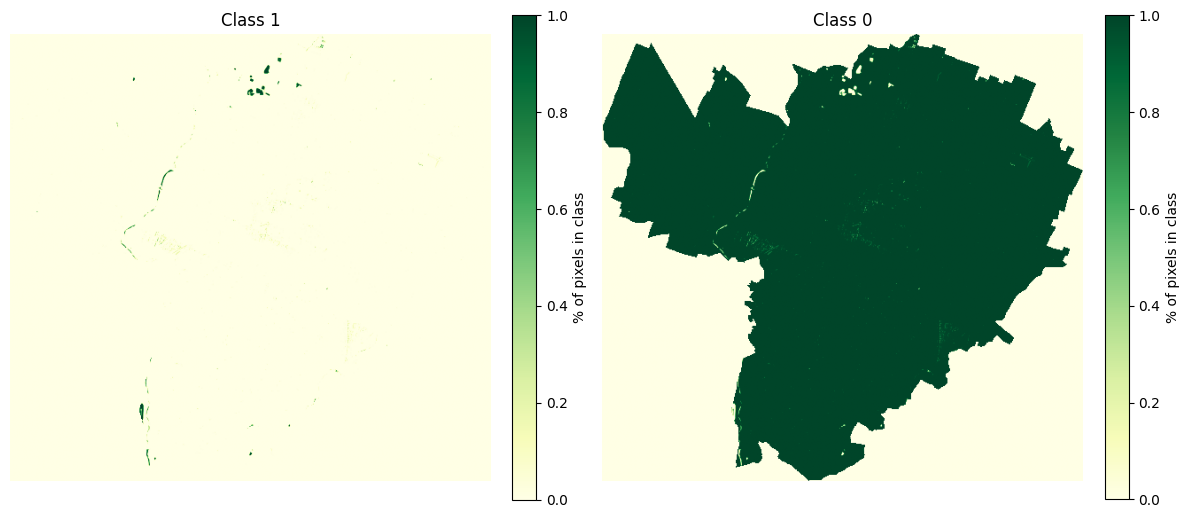

In [ ]:
ndwi_paths = {
    "Class 1": "ndwi_pct_30m/ndwi_class1_total_30m.tif",
    "Class 0": "ndwi_pct_30m/ndwi_class0_total_30m.tif"
}

gdf = gpd.read_file(bound)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (label, path) in zip(axes, ndwi_paths.items()):
    with rasterio.open(path) as src:
        out_image, out_transform = mask(src, gdf.geometry, crop=True)
        out_image = out_image[0]  

        img = ax.imshow(out_image, cmap="YlGn")
        ax.set_title(label)
        ax.axis("off")

    # Add individual colorbar for each subplot
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("% of pixels in class")

plt.tight_layout()
plt.show()


## moving windows (1 to 20 for each class)

### NDVI

In [ ]:
import rasterio
import numpy as np
from scipy.ndimage import uniform_filter
import os

# NDVI Rasters by class
ndvi_rasters = {
    "class1": "ndvi_pct_30m/ndvi_class1_total_30m.tif",
    "class0p5": "ndvi_pct_30m/ndvi_class0p5_total_30m.tif",
    "class0": "ndvi_pct_30m/ndvi_class0_total_30m.tif"
}

output_folder = "ndvi_pct_30m_moving_window/"
os.makedirs(output_folder, exist_ok=True)

# Loop over classes
for class_name, path in ndvi_rasters.items():
    with rasterio.open(path) as src:
        data = src.read(1)
        profile = src.profile

        # Loop over window sizes
        for window_size in range(1, 21):  
            # Apply moving window (uniform_filter calculates the average)
            smoothed = uniform_filter(data, size=window_size, mode='nearest')

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(output_folder, f"{class_name}_window{window_size}.tif")

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)

            print(f"Saved {out_path}")


Guardado ndvi_pct_30m_moving_window/class1_window1.tif
Guardado ndvi_pct_30m_moving_window/class1_window2.tif
Guardado ndvi_pct_30m_moving_window/class1_window3.tif
Guardado ndvi_pct_30m_moving_window/class1_window4.tif
Guardado ndvi_pct_30m_moving_window/class1_window5.tif
Guardado ndvi_pct_30m_moving_window/class1_window6.tif
Guardado ndvi_pct_30m_moving_window/class1_window7.tif
Guardado ndvi_pct_30m_moving_window/class1_window8.tif
Guardado ndvi_pct_30m_moving_window/class1_window9.tif
Guardado ndvi_pct_30m_moving_window/class1_window10.tif
Guardado ndvi_pct_30m_moving_window/class1_window11.tif
Guardado ndvi_pct_30m_moving_window/class1_window12.tif
Guardado ndvi_pct_30m_moving_window/class1_window13.tif
Guardado ndvi_pct_30m_moving_window/class1_window14.tif
Guardado ndvi_pct_30m_moving_window/class1_window15.tif
Guardado ndvi_pct_30m_moving_window/class1_window16.tif
Guardado ndvi_pct_30m_moving_window/class1_window17.tif
Guardado ndvi_pct_30m_moving_window/class1_window18.tif
G

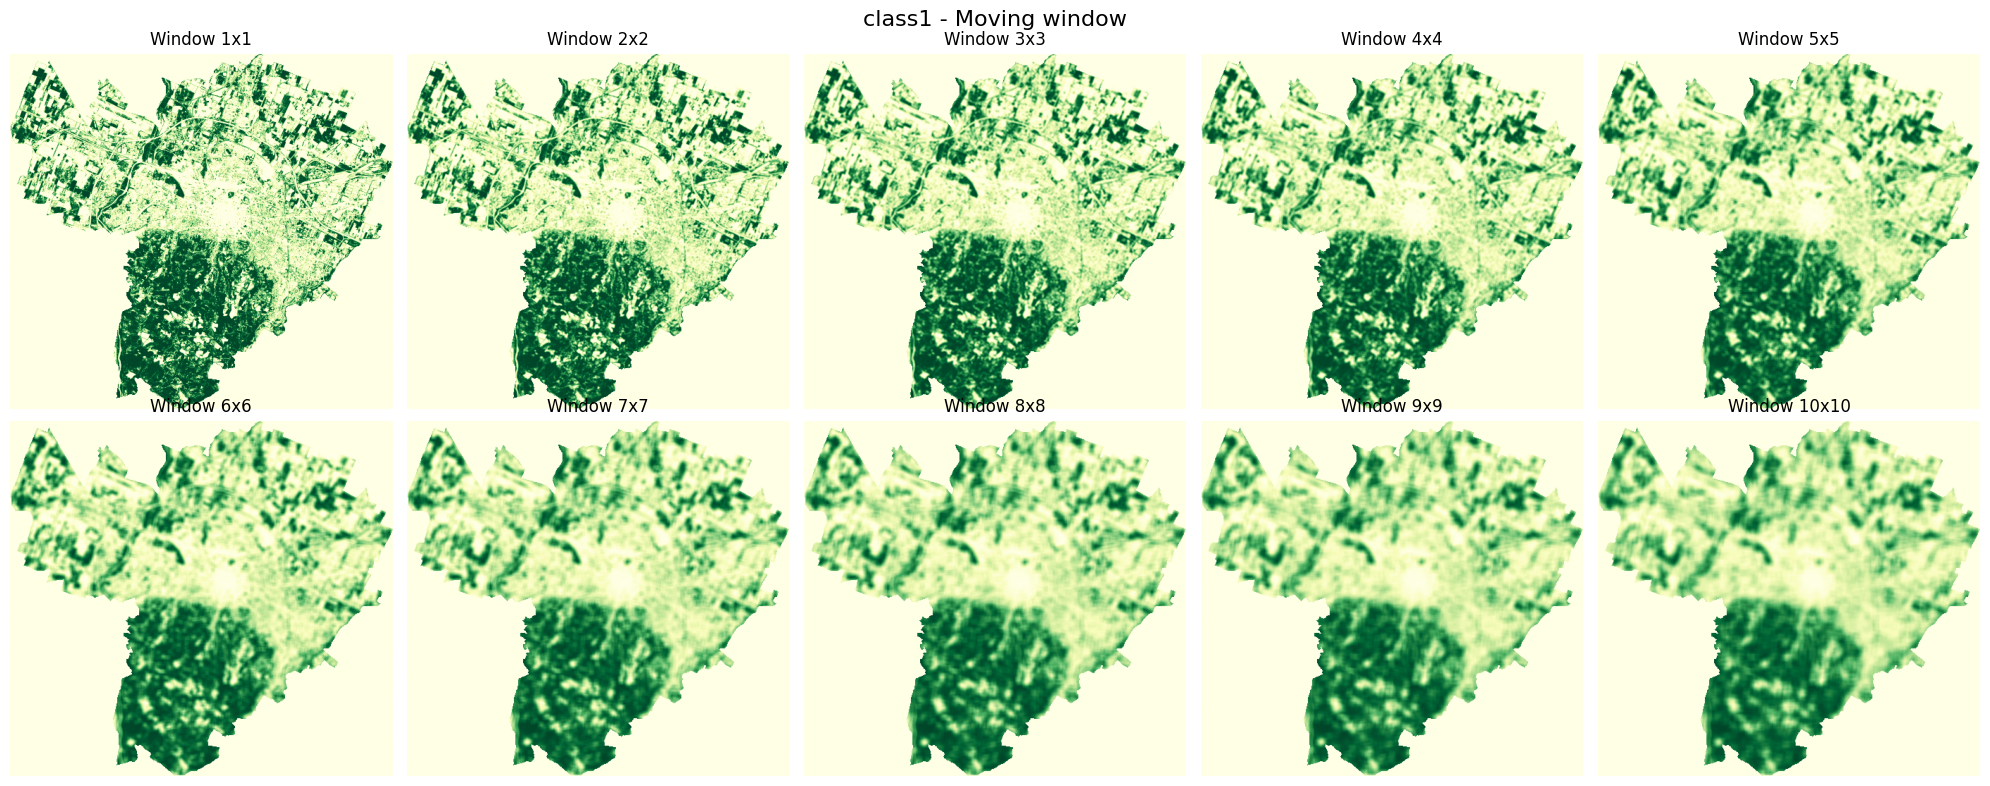

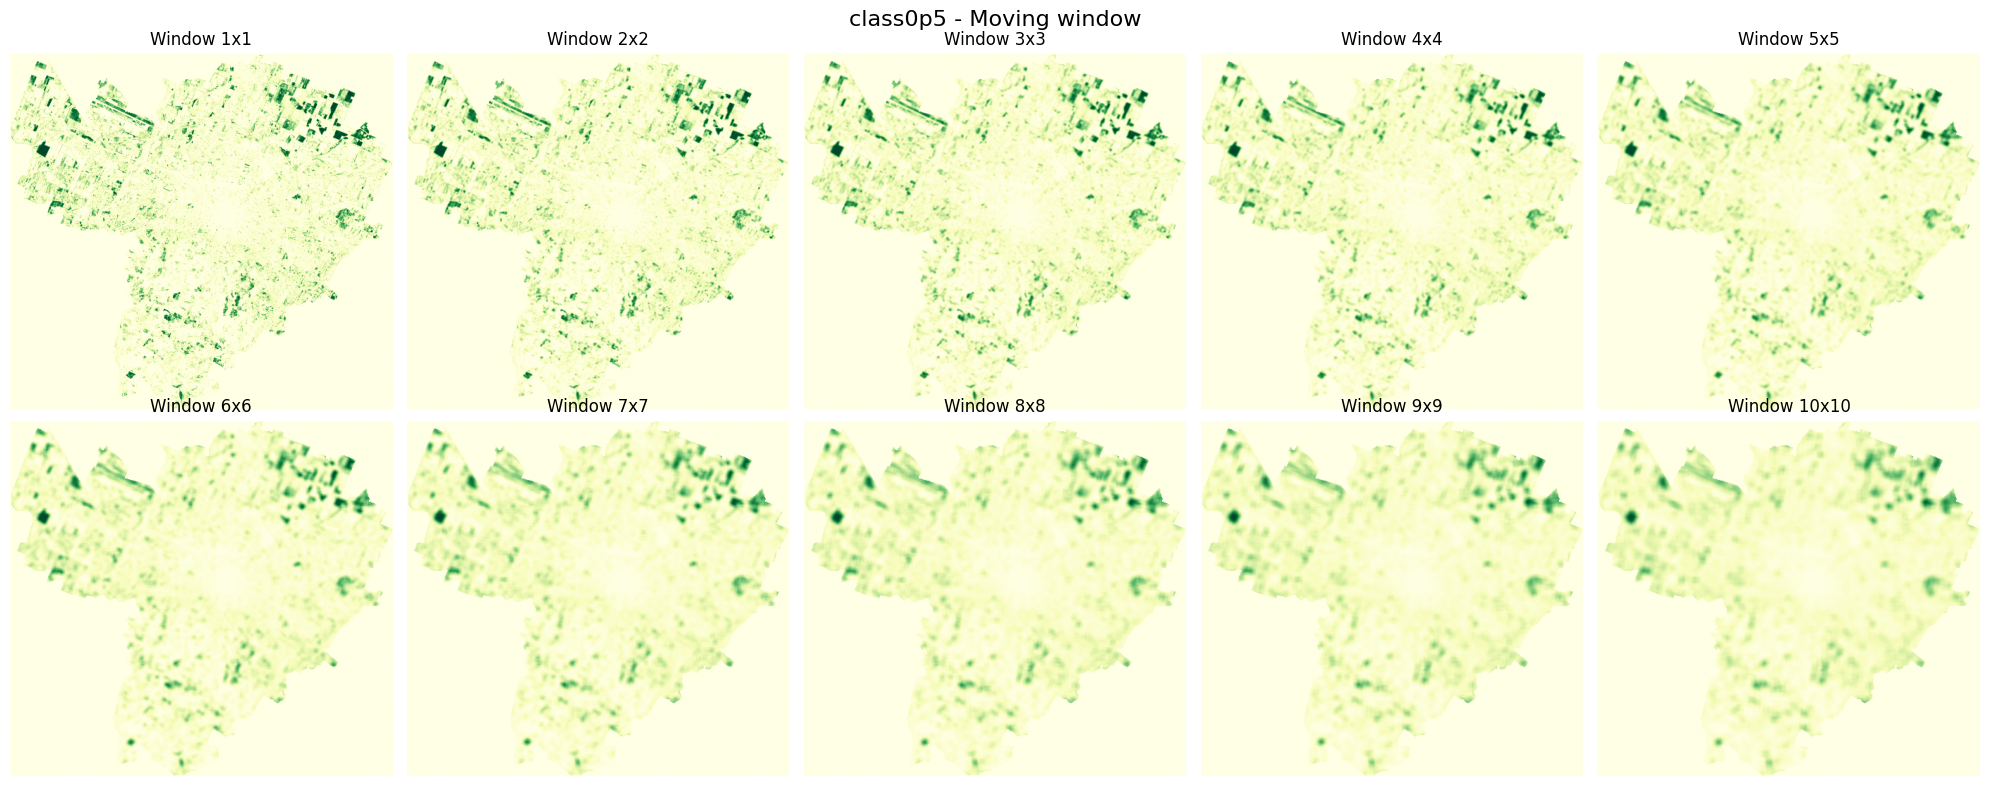

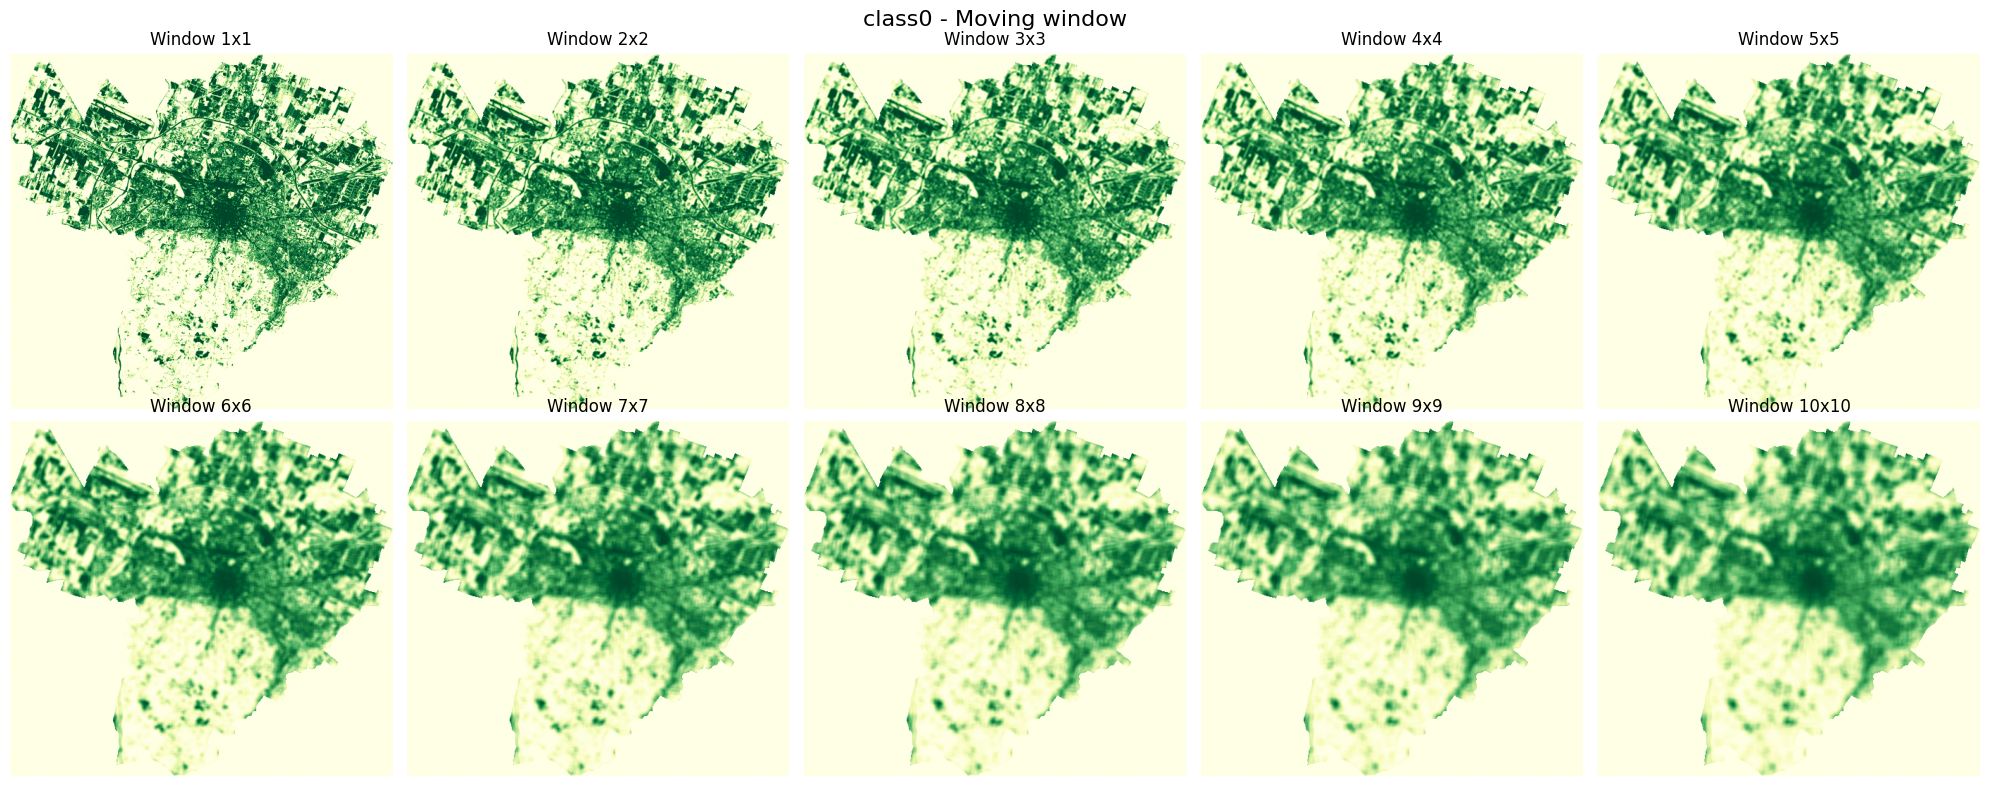

In [ ]:
classes = ["class1", "class0p5", "class0"]

gdf = gpd.read_file(bound)

for class_name in classes:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2 rows x 5 columns = 10 windows
    axes = axes.flatten()

    for window_size in range(1, 11):
        raster_path = os.path.join(output_folder, f"{class_name}_window{window_size}.tif")
        with rasterio.open(raster_path) as src:
            # Crop to boundary
            data, out_transform = mask(src, gdf.geometry, crop=True)
            data = data[0]  # only first band

        ax = axes[window_size-1]
        im = ax.imshow(data, cmap="YlGn")
        ax.set_title(f"Window {window_size}x{window_size}")
        ax.axis("off")


    fig.suptitle(f"{class_name} - Moving window", fontsize=16)
    plt.tight_layout()
    plt.show()



### NDWI

In [ ]:
import rasterio
import numpy as np
from scipy.ndimage import uniform_filter
import os

# NDWI Rasters by class
ndwi_rasters = {
    "class1": "ndwi_pct_30m/ndwi_class1_total_30m.tif",
    "class0": "ndwi_pct_30m/ndwi_class0_total_30m.tif"
}

output_folder = "ndwi_pct_30m_moving_window/"
os.makedirs(output_folder, exist_ok=True)

# Loop over classes
for class_name, path in ndwi_rasters.items():
    with rasterio.open(path) as src:
        data = src.read(1)
        profile = src.profile

        # Loop over window sizes
        for window_size in range(1, 21):  
            # Apply moving window (uniform_filter calculates the average)
            smoothed = uniform_filter(data, size=window_size, mode='nearest')

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(output_folder, f"{class_name}_window{window_size}.tif")

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)

            print(f"Saved {out_path}")

Guardado ndwi_pct_30m_moving_window/class1_window1.tif
Guardado ndwi_pct_30m_moving_window/class1_window2.tif
Guardado ndwi_pct_30m_moving_window/class1_window3.tif
Guardado ndwi_pct_30m_moving_window/class1_window4.tif
Guardado ndwi_pct_30m_moving_window/class1_window5.tif
Guardado ndwi_pct_30m_moving_window/class1_window6.tif
Guardado ndwi_pct_30m_moving_window/class1_window7.tif
Guardado ndwi_pct_30m_moving_window/class1_window8.tif
Guardado ndwi_pct_30m_moving_window/class1_window9.tif
Guardado ndwi_pct_30m_moving_window/class1_window10.tif
Guardado ndwi_pct_30m_moving_window/class1_window11.tif
Guardado ndwi_pct_30m_moving_window/class1_window12.tif
Guardado ndwi_pct_30m_moving_window/class1_window13.tif
Guardado ndwi_pct_30m_moving_window/class1_window14.tif
Guardado ndwi_pct_30m_moving_window/class1_window15.tif
Guardado ndwi_pct_30m_moving_window/class1_window16.tif
Guardado ndwi_pct_30m_moving_window/class1_window17.tif
Guardado ndwi_pct_30m_moving_window/class1_window18.tif
G

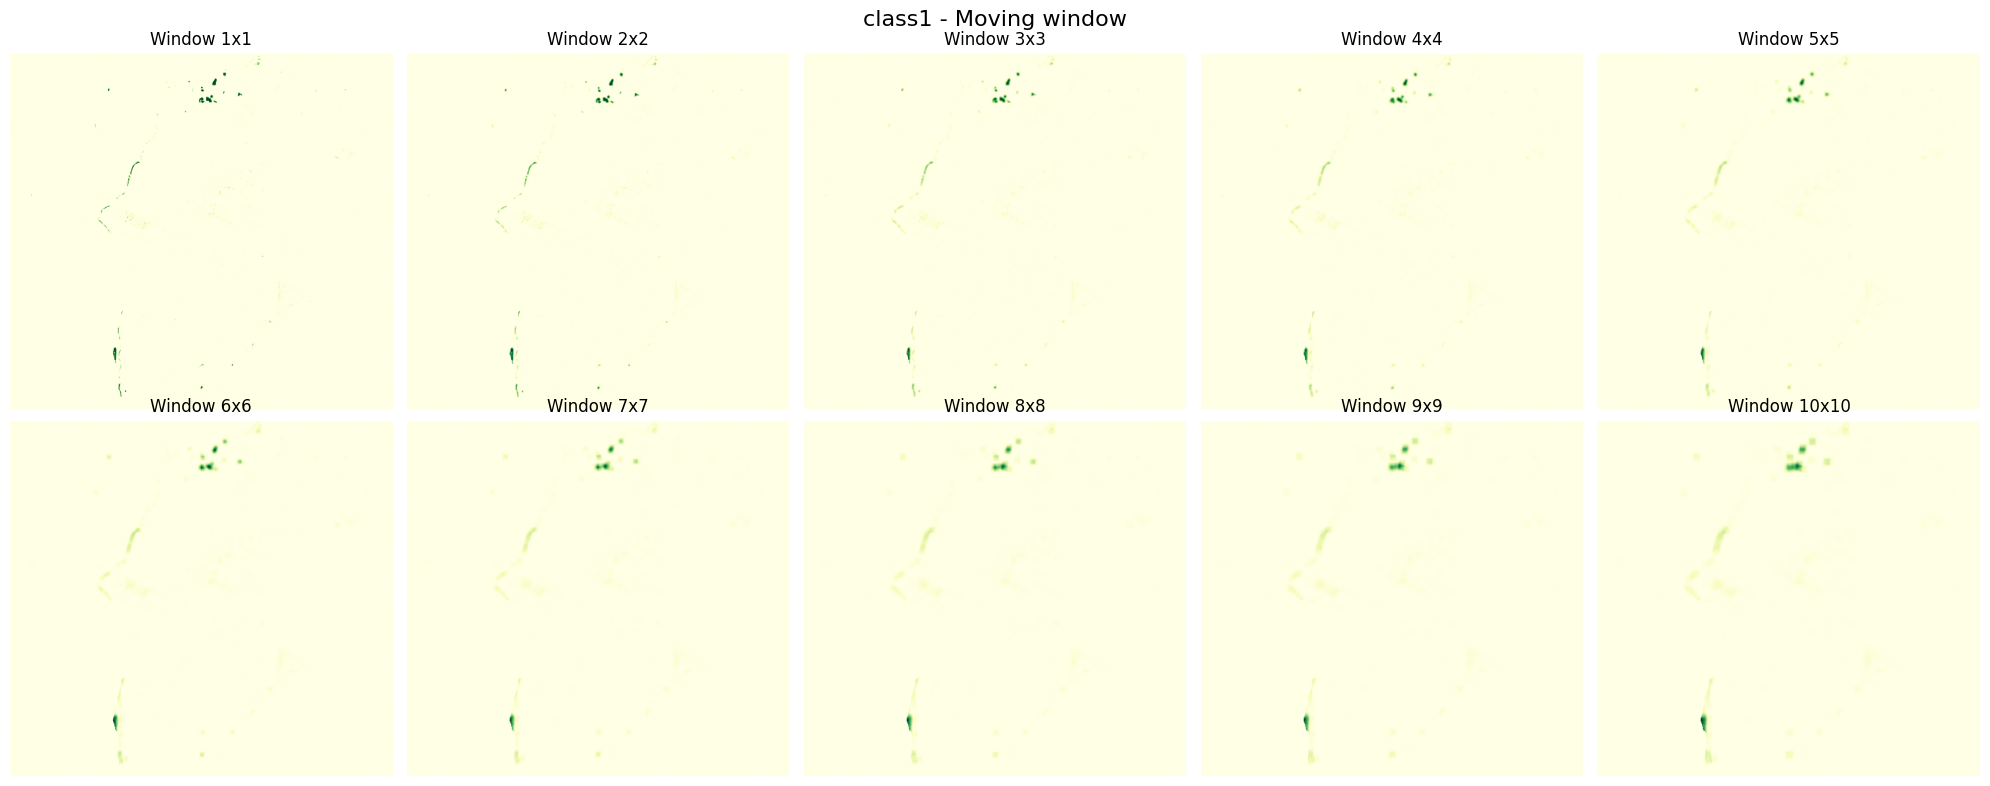

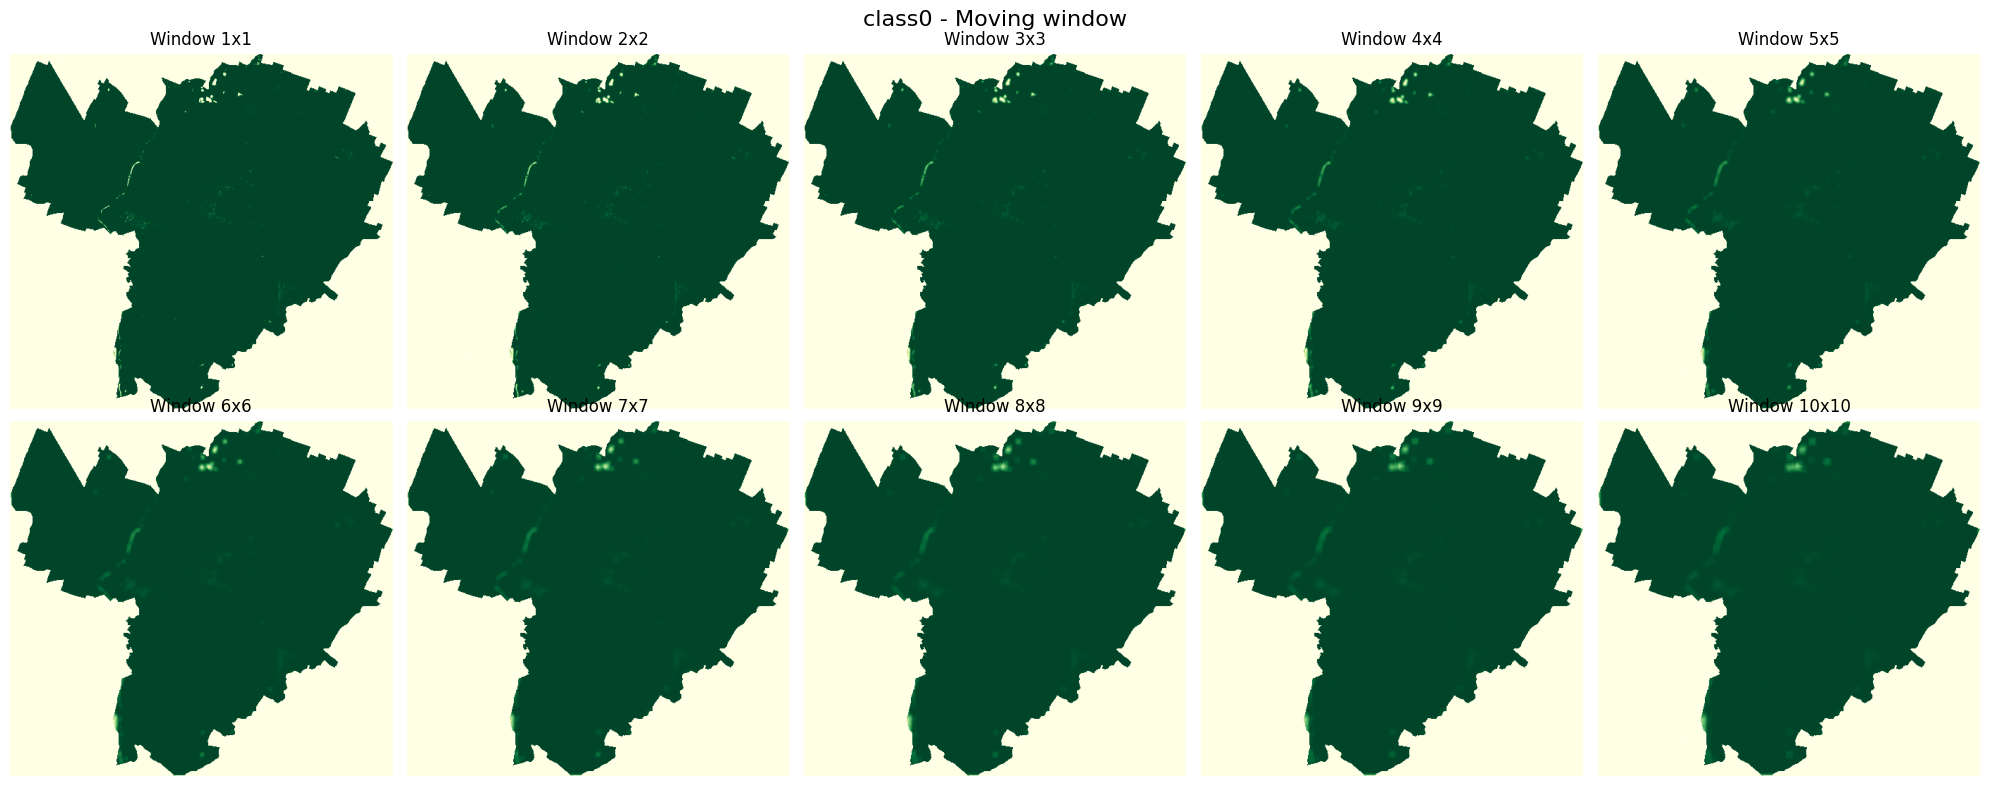

In [ ]:
classes = ["class1", "class0"]

gdf = gpd.read_file(bound)

for class_name in classes:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # 2 rows x 5 columns = 10 windows
    axes = axes.flatten()

    for window_size in range(1, 11):
        raster_path = os.path.join(output_folder, f"{class_name}_window{window_size}.tif")
        with rasterio.open(raster_path) as src:
            # Crop to boundary
            data, out_transform = mask(src, gdf.geometry, crop=True)
            data = data[0]  # only first band

        ax = axes[window_size-1]
        im = ax.imshow(data, cmap="YlGn")
        ax.set_title(f"Window {window_size}x{window_size}")
        ax.axis("off")


    fig.suptitle(f"{class_name} - Moving window", fontsize=16)
    plt.tight_layout()
    plt.show()


## Correlations with LST

### NDVI

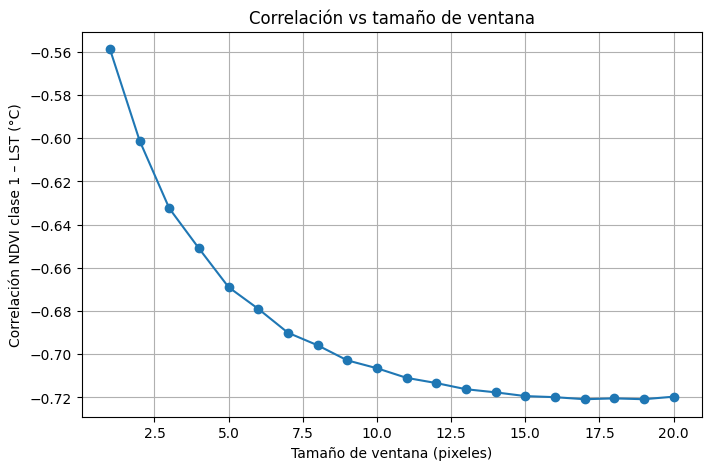

In [ ]:
# --- Paths ---
ndvi_folder = "ndvi_pct_30m_moving_window/"
window_sizes = range(1, 21)

# --- Load boundary ---
gdf = gpd.read_file(bound)

# --- Load and crop LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # apply transformation

# --- Assign nodata to LST < 0 --- (nodata is -124)
lst_crop[lst_crop < 0] = np.nan

correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class1_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        gdf_ndvi = gdf.to_crs(src_ndvi.crs)
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf_ndvi.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # --- Reproject NDVI to LST grid if CRS or shape differ ---
    if src_ndvi.crs != lst_crs or ndvi_crop.shape != lst_crop.shape:
        ndvi_reproj = np.empty_like(lst_crop, dtype=np.float32)
        reproject(
            source=ndvi_crop,
            destination=ndvi_reproj,
            src_transform=ndvi_transform,
            src_crs=src_ndvi.crs,
            dst_transform=lst_transform,
            dst_crs=lst_crs,
            resampling=Resampling.bilinear
        )
    else:
        ndvi_reproj = ndvi_crop

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_reproj[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 1 – LST (°C)")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()



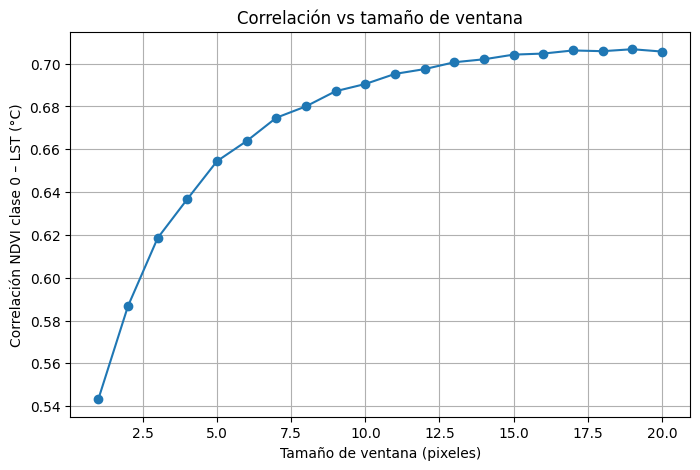

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import os
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

# --- Paths ---
ndvi_folder = "ndvi_pct_30m_moving_window/"
window_sizes = range(1, 21)

# --- Load boundary ---
gdf = gpd.read_file(bound)

# --- Load and crop LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # transformation

# --- Assign nodata to LST < 0 (nodata is -124) --- 
lst_crop[lst_crop < 0] = np.nan

correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class0_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        gdf_ndvi = gdf.to_crs(src_ndvi.crs)
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf_ndvi.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # --- Reproject NDVI to LST grid if CRS or shape differ ---
    if src_ndvi.crs != lst_crs or ndvi_crop.shape != lst_crop.shape:
        ndvi_reproj = np.empty_like(lst_crop, dtype=np.float32)
        reproject(
            source=ndvi_crop,
            destination=ndvi_reproj,
            src_transform=ndvi_transform,
            src_crs=src_ndvi.crs,
            dst_transform=lst_transform,
            dst_crs=lst_crs,
            resampling=Resampling.bilinear
        )
    else:
        ndvi_reproj = ndvi_crop

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_reproj[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación NDVI clase 0 – LST (°C)")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()



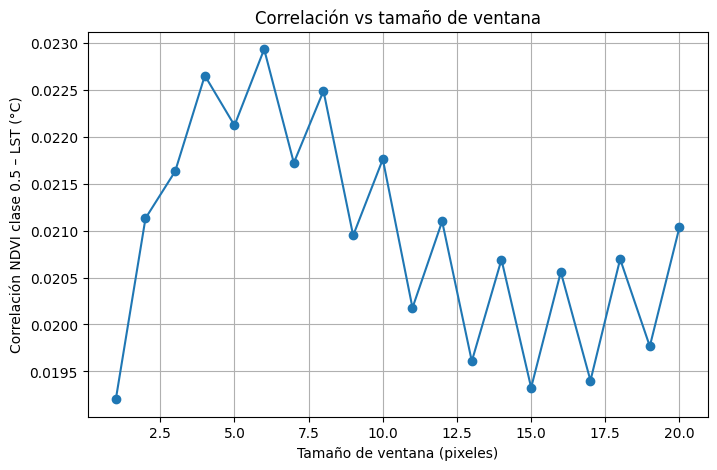

In [ ]:
# --- Paths ---
ndvi_folder = "ndvi_pct_30m_moving_window/"
window_sizes = range(1, 21)

# --- Load boundary ---
gdf = gpd.read_file(bound)

# --- Load and crop LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # apply transformation

# --- Assign nodata to LST < 0 (nodata is -124) ---
lst_crop[lst_crop < 0] = np.nan

correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class0p5_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        gdf_ndvi = gdf.to_crs(src_ndvi.crs)
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf_ndvi.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # --- Reproject NDVI to LST grid if CRS or shape differ ---
    if src_ndvi.crs != lst_crs or ndvi_crop.shape != lst_crop.shape:
        ndvi_reproj = np.empty_like(lst_crop, dtype=np.float32)
        reproject(
            source=ndvi_crop,
            destination=ndvi_reproj,
            src_transform=ndvi_transform,
            src_crs=src_ndvi.crs,
            dst_transform=lst_transform,
            dst_crs=lst_crs,
            resampling=Resampling.bilinear
        )
    else:
        ndvi_reproj = ndvi_crop

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_reproj[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación NDVI clase 0.5 – LST (°C)")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()


### NDWI

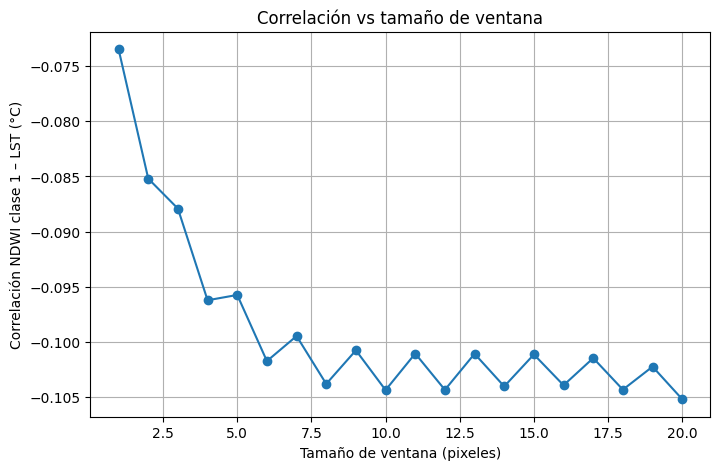

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import os
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

# --- Paths ---
ndwi_folder = "ndwi_pct_30m_moving_window/"
window_sizes = range(1, 21)

# --- Load boundary ---
gdf = gpd.read_file(bound)

# --- Load and crop LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # apply transformation

# --- Assign nodata to LST < 0 ---
lst_crop[lst_crop < 0] = np.nan

correlations = []

for w in window_sizes:
    ndwi_path = os.path.join(ndwi_folder, f"class1_window{w}.tif")
    with rasterio.open(ndwi_path) as src_ndwi:
        gdf_ndwi = gdf.to_crs(src_ndwi.crs)
        ndwi_crop, ndwi_transform = mask(src_ndwi, gdf_ndwi.geometry, crop=True)
        ndwi_crop = ndwi_crop[0].astype(float)

    # --- Reproject NDWI to LST grid if CRS or shape differ ---
    if src_ndwi.crs != lst_crs or ndwi_crop.shape != lst_crop.shape:
        ndwi_reproj = np.empty_like(lst_crop, dtype=np.float32)
        reproject(
            source=ndwi_crop,
            destination=ndwi_reproj,
            src_transform=ndwi_transform,
            src_crs=src_ndwi.crs,
            dst_transform=lst_transform,
            dst_crs=lst_crs,
            resampling=Resampling.bilinear
        )
    else:
        ndwi_reproj = ndwi_crop

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop)  
    ndwi_vals = ndwi_reproj[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(ndwi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación NDWI clase 1 – LST (°C)")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()

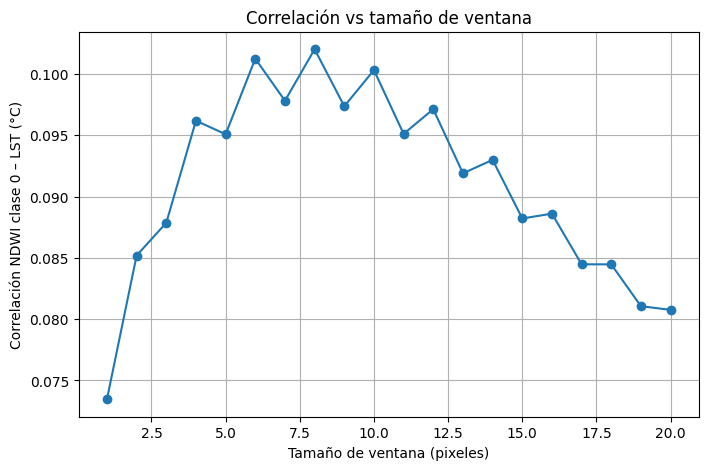

In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import os
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

# --- Paths ---
ndwi_folder = "ndwi_pct_30m_moving_window/"
window_sizes = range(1, 21)

# --- Load boundary ---
gdf = gpd.read_file(bound)

# --- Load and crop LST ---
with rasterio.open(lst_path) as src_lst:
    lst_crs = src_lst.crs
    gdf_lst = gdf.to_crs(lst_crs)
    lst_crop, lst_transform = mask(src_lst, gdf_lst.geometry, crop=True)
    lst_crop = lst_crop[0].astype(float) * 0.00341802 - 124.15  # apply transformation

# --- Assign nodata to LST < 0 --- (nodata is -124)
lst_crop[lst_crop < 0] = np.nan

correlations = []

for w in window_sizes:
    ndwi_path = os.path.join(ndwi_folder, f"class0_window{w}.tif")
    with rasterio.open(ndwi_path) as src_ndwi:
        gdf_ndwi = gdf.to_crs(src_ndwi.crs)
        ndwi_crop, ndwi_transform = mask(src_ndwi, gdf_ndwi.geometry, crop=True)
        ndwi_crop = ndwi_crop[0].astype(float)

    # --- Reproject NDWI to LST grid if CRS or shape differ ---
    if src_ndwi.crs != lst_crs or ndwi_crop.shape != lst_crop.shape:
        ndwi_reproj = np.empty_like(lst_crop, dtype=np.float32)
        reproject(
            source=ndwi_crop,
            destination=ndwi_reproj,
            src_transform=ndwi_transform,
            src_crs=src_ndwi.crs,
            dst_transform=lst_transform,
            dst_crs=lst_crs,
            resampling=Resampling.bilinear
        )
    else:
        ndwi_reproj = ndwi_crop

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_crop)  # only ignore pixels where LST < 0
    ndwi_vals = ndwi_reproj[valid_mask]
    lst_vals = lst_crop[valid_mask]

    corr = np.corrcoef(ndwi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Tamaño de ventana (pixeles)")
plt.ylabel("Correlación NDWI clase 0 – LST (°C)")
plt.title("Correlación vs tamaño de ventana")
plt.grid(True)
plt.show()